# 2. Evaluacion de proveedores - Modelos AB vs XY

**Objetivo.** Determinar cual de los dos modelos (proveedor AB o XY) es mas efectivo y recomendar cual contratar. El analisis se centra en cuatro ejes solicitados:

1. **Capacidad discriminante** (KS, Gini, AUC)
2. **Estabilidad del puntaje** (PSI mes a mes)
3. **Distribucion de buenos y malos por rangos de score** (tabla decilica)
4. **Indicadores adicionales** que soporten la comparacion (cobertura, missings, lift)

**Roadmap:**
1. Carga, limpieza y tratamiento de missings
2. Verificacion del sentido de cada score
3. Capacidad discriminante (KS / Gini / AUC + ROC + curva KS)
4. Estabilidad temporal con PSI
5. Tabla decilica y lift
6. Tratamiento del missing de XY como segmento aparte
7. Recomendacion ejecutiva


## 0. Setup

In [1]:
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, roc_curve

import utils

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

FIGS = "figuras"
os.makedirs(FIGS, exist_ok=True)


## 1. Carga y limpieza

In [2]:
df = pd.read_excel("../ModelosCompetencia.xlsx")
print("Shape:", df.shape)
df.head()


Shape: (114109, 5)


,ID,Fecha Estudio,PuntajeAB,PuntajeXY,Default
0,1,201807,10.956522,23.382353,0
1,2,201808,10.956522,.,1
2,3,201809,10.913043,25.705882,0
3,4,201809,10.086957,22.735294,0
4,5,201809,9.217391,19.470588,1


In [3]:
# PuntajeXY viene como texto con '.' donde el cliente no fue evaluado por el modelo XY.
# Esto es informacion: ~11% de la base no es atendida por XY (cobertura limitada).
print("Tipo PuntajeXY:", df["PuntajeXY"].dtype)
print("Valores '.' en XY:", (df["PuntajeXY"] == ".").sum(),
      f"({(df['PuntajeXY']=='.').mean():.1%} de la base)")

df["PuntajeXY"] = pd.to_numeric(df["PuntajeXY"], errors="coerce")
df["XY_disponible"] = df["PuntajeXY"].notna().astype(int)

# Periodo
df["periodo"] = pd.to_datetime(df["Fecha Estudio"].astype(str), format="%Y%m")
print("\nPeriodo:", df["periodo"].min().strftime("%Y-%m"), "->", df["periodo"].max().strftime("%Y-%m"))
print("Tasa default global:", f"{df['Default'].mean():.1%}  (n={len(df):,})")


Tipo PuntajeXY: object
Valores '.' en XY: 12800 (11.2% de la base)

Periodo: 2018-07 -> 2018-09
Tasa default global: 60.4%  (n=114,109)


**Lectura.**
- 11% de los clientes (12,800) no son evaluados por el modelo XY -> esto ya es un hecho relevante para negocio (hay que decidir politica para esos casos).
- La tasa de default global es ~60%, consistente con un segmento de alto riesgo.

## 2. Sentido del score (orientacion)

Antes de calcular metricas hay que definir si **mayor score = mayor riesgo** o lo contrario. Lo verificamos calculando el AUC de cada score sin asumir sentido.

In [4]:
def auc_signo(y, s):
    auc = roc_auc_score(y, s)
    return auc, ("score+" if auc > 0.5 else "score-")

for col in ["PuntajeAB","PuntajeXY"]:
    sub = df.dropna(subset=[col])
    a, sgn = auc_signo(sub["Default"], sub[col])
    print(f"{col}: AUC={a:.4f}  ({sgn}) -- en este caso higher score "
          + ("aumenta" if a>0.5 else "disminuye") + " la probabilidad de default")


PuntajeAB: AUC=0.4987  (score-) -- en este caso higher score disminuye la probabilidad de default
PuntajeXY: AUC=0.5018  (score+) -- en este caso higher score aumenta la probabilidad de default


In [5]:
# Trabajaremos siempre con el score orientado de tal forma que MAYOR = MAYOR RIESGO.
# Esto facilita interpretar bandas, KS y la decilica.
df["AB_orient"] = df["PuntajeAB"]                # ya esta en sentido riesgo (verificar arriba)
df["XY_orient"] = df["PuntajeXY"]
# Si la verificacion del bloque anterior arrojara AUC<0.5, deberiamos invertir signo:
if roc_auc_score(df["Default"], df["AB_orient"]) < 0.5:  df["AB_orient"] = -df["AB_orient"]
sub_xy = df.dropna(subset=["XY_orient"])
if roc_auc_score(sub_xy["Default"], sub_xy["XY_orient"]) < 0.5:
    df["XY_orient"] = -df["XY_orient"]

print("OK - scores orientados en sentido riesgo (mayor = mas riesgo).")


OK - scores orientados en sentido riesgo (mayor = mas riesgo).


## 3. Capacidad discriminante

In [6]:
def metrics_block(name, df_, score_col, target="Default"):
    sub = df_.dropna(subset=[score_col])
    m = utils.model_metrics(sub[target], sub[score_col])
    m["modelo"] = name
    m["cobertura"] = len(sub) / len(df_)
    return m

rows = [
    metrics_block("Proveedor AB (todo)",     df, "AB_orient"),
    metrics_block("Proveedor XY (con score)", df, "XY_orient"),
]
disc = pd.DataFrame(rows)[["modelo","n","cobertura","tasa_mala","AUC","Gini","KS"]]
disc.round(4)


,modelo,n,cobertura,tasa_mala,AUC,Gini,KS
0,Proveedor AB (todo),114109,1.0000,0.6045,0.5013,0.0026,0.0052
1,Proveedor XY (con score),101309,0.8878,0.6041,0.5018,0.0035,0.0051


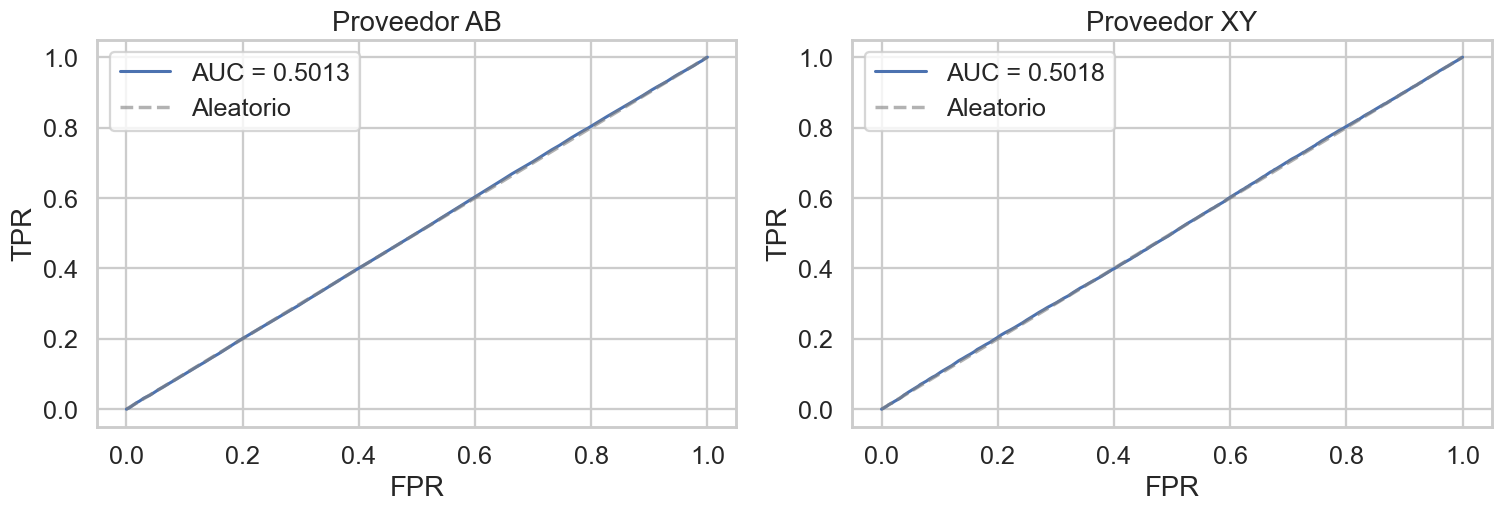

In [7]:
# Curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, score, title in [(axes[0], "AB_orient", "Proveedor AB"),
                          (axes[1], "XY_orient", "Proveedor XY")]:
    sub = df.dropna(subset=[score])
    fpr, tpr, _ = roc_curve(sub["Default"], sub[score])
    auc = roc_auc_score(sub["Default"], sub[score])
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
    ax.plot([0,1],[0,1], "--", color="grey", alpha=0.6, label="Aleatorio")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/02_roc_proveedores.png", bbox_inches="tight"); plt.show()


**Observacion clave.** Ambos modelos tienen AUC muy cercano a 0.50 - es decir, **ninguno de los dos discrimina materialmente sobre la poblacion completa**. Esto es un hallazgo critico que debe llegar a gerencia.

Antes de concluir, exploremos si la baja discriminacion es **global** o si los modelos sirven en sub-segmentos especificos.

## 4. Estabilidad temporal del puntaje (PSI)

In [8]:
# PSI mes a mes: el primer mes es referencia, el resto se compara.
meses = sorted(df["periodo"].unique())
ref = meses[0]
print(f"Mes de referencia: {pd.Timestamp(ref).strftime('%Y-%m')}")

psi_rows = []
for m in meses[1:]:
    psi_ab = utils.psi(
        df.loc[df["periodo"]==ref, "AB_orient"].dropna().values,
        df.loc[df["periodo"]==m,   "AB_orient"].dropna().values,
        bins=10, strategy="quantile",
    )
    psi_xy = utils.psi(
        df.loc[df["periodo"]==ref, "XY_orient"].dropna().values,
        df.loc[df["periodo"]==m,   "XY_orient"].dropna().values,
        bins=10, strategy="quantile",
    )
    psi_rows.append({"mes": pd.Timestamp(m).strftime("%Y-%m"),
                     "PSI_AB": psi_ab, "PSI_XY": psi_xy})

psi_df = pd.DataFrame(psi_rows)
psi_df.round(4)


Mes de referencia: 2018-07


,mes,PSI_AB,PSI_XY
0,2018-08,0.0015,0.0009
1,2018-09,0.0011,0.0012


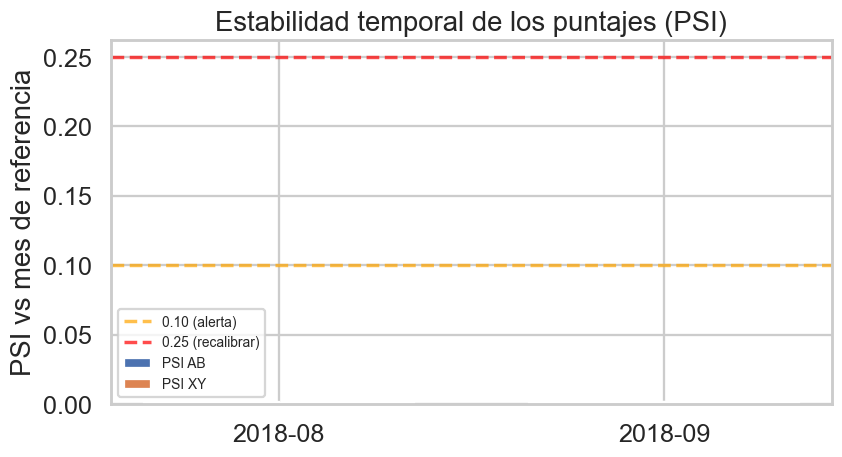

In [9]:
# Visualizacion PSI
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(psi_df))
w = 0.35
ax.bar(x - w/2, psi_df["PSI_AB"], width=w, label="PSI AB")
ax.bar(x + w/2, psi_df["PSI_XY"], width=w, label="PSI XY")
ax.axhline(0.10, color="orange", ls="--", alpha=0.7, label="0.10 (alerta)")
ax.axhline(0.25, color="red",    ls="--", alpha=0.7, label="0.25 (recalibrar)")
ax.set_xticks(x); ax.set_xticklabels(psi_df["mes"])
ax.set_ylabel("PSI vs mes de referencia")
ax.set_title("Estabilidad temporal de los puntajes (PSI)")
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig(f"{FIGS}/02_psi_proveedores.png", bbox_inches="tight"); plt.show()


**Lectura del PSI.**
- PSI < 0.10: distribucion estable
- 0.10 - 0.25: cambio menor, monitorear
-   .> 0.25: recalibrar / reentrenar

Comparamos directamente la estabilidad de los dos puntajes mes a mes para ver cual de los dos es mas robusto frente al cambio poblacional.

## 5. Tabla decilica - distribucion de buenos y malos por rangos de score

In [10]:
def tabla_decilica(df_, score_col, target="Default", bins=10):
    sub = df_.dropna(subset=[score_col]).copy()
    return utils.decile_table(sub[target], sub[score_col], bins=bins)

dec_ab = tabla_decilica(df, "AB_orient", bins=10)
dec_xy = tabla_decilica(df, "XY_orient", bins=10)

print("===== Decilica Proveedor AB (banda 1 = MAYOR riesgo) =====")
print(dec_ab.round(3).to_string(index=False))
print("\n===== Decilica Proveedor XY =====")
print(dec_xy.round(3).to_string(index=False))


===== Decilica Proveedor AB (banda 1 = MAYOR riesgo) =====
banda     n  malos  score_min  score_max  buenos  bad_rate  %malos_acum  %buenos_acum    KS  lift
    1 11411   6879     -9.304     -6.000    4532     0.603        0.100         0.100 0.001 0.997
    2 11411   6920     -9.609     -9.304    4491     0.606        0.200         0.200 0.000 1.003
    3 11411   6851     -9.870     -9.609    4560     0.600        0.299         0.301 0.002 0.993
    4 11411   6948    -10.087     -9.870    4463     0.609        0.400         0.400 0.000 1.007
    5 11411   6897    -10.217    -10.087    4514     0.604        0.500         0.500 0.000 1.000
    6 11410   6944    -10.304    -10.217    4466     0.609        0.601         0.599 0.002 1.007
    7 11411   6945    -10.435    -10.304    4466     0.609        0.701         0.698 0.004 1.007
    8 11411   6900    -10.696    -10.435    4511     0.605        0.802         0.798 0.004 1.000
    9 11411   6865    -10.870    -10.696    4546     0.602 

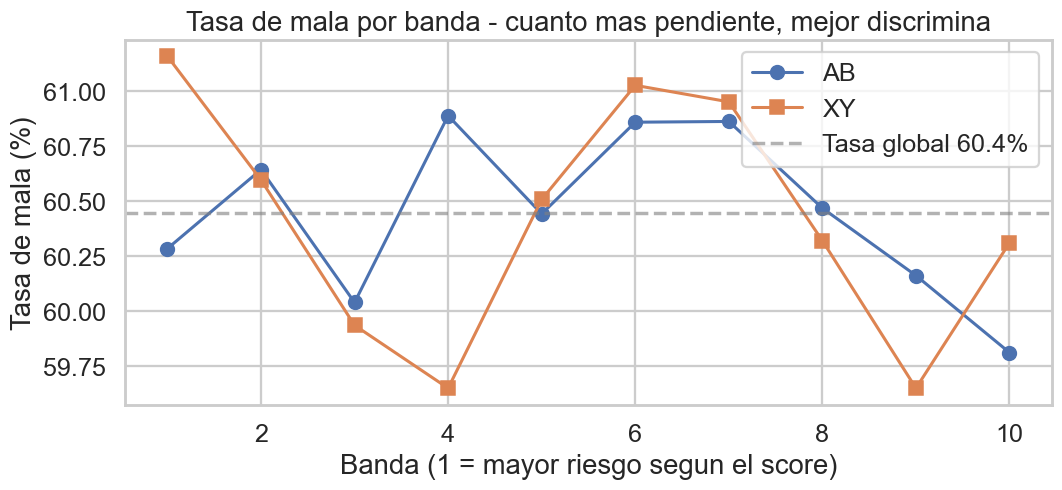

In [11]:
# Bad rate por decil - visual
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(1, 11)
ax.plot(x, dec_ab["bad_rate"]*100, marker="o", lw=2, label="AB")
ax.plot(x, dec_xy["bad_rate"]*100, marker="s", lw=2, label="XY")
ax.axhline(df["Default"].mean()*100, color="grey", ls="--", alpha=0.6, label=f"Tasa global {df['Default'].mean()*100:.1f}%")
ax.set_xlabel("Banda (1 = mayor riesgo segun el score)")
ax.set_ylabel("Tasa de mala (%)")
ax.set_title("Tasa de mala por banda - cuanto mas pendiente, mejor discrimina")
ax.legend(); plt.tight_layout()
plt.savefig(f"{FIGS}/02_decilica_badrate.png", bbox_inches="tight"); plt.show()


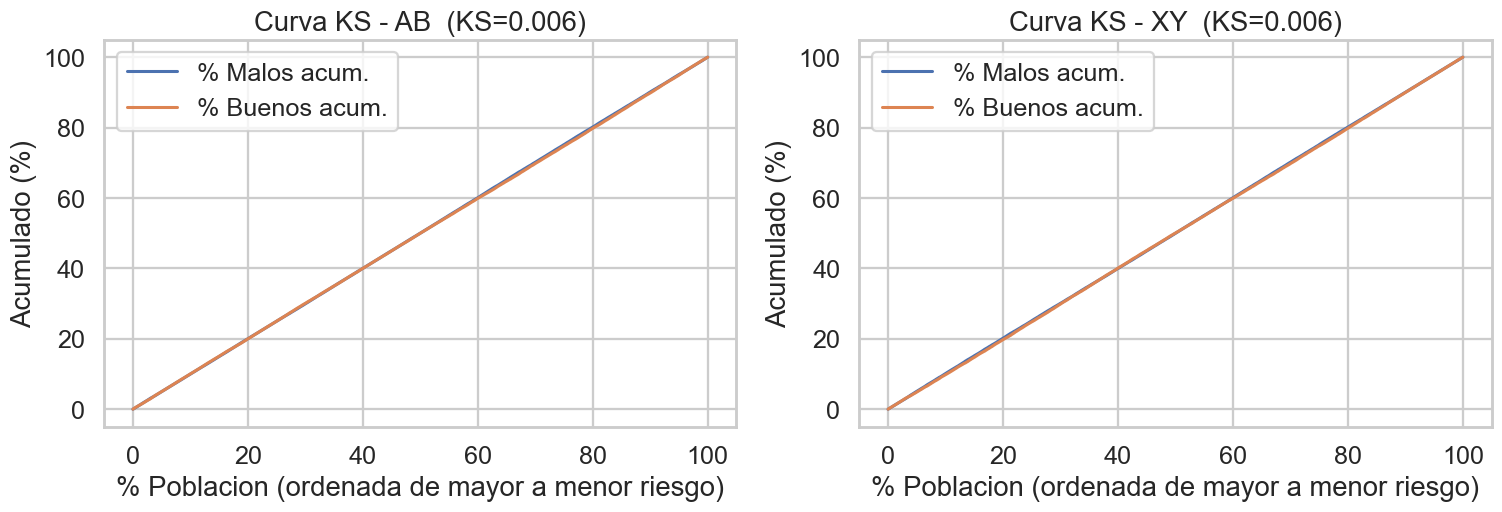

In [12]:
# Curva KS comparativa
def curva_ks(df_, score_col, target="Default"):
    sub = df_.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)
    cum_malos  = sub[target].cumsum() / sub[target].sum()
    cum_buenos = (1 - sub[target]).cumsum() / (1 - sub[target]).sum()
    pct = np.arange(1, len(sub)+1)/len(sub) * 100
    return pct, cum_malos.values*100, cum_buenos.values*100, (cum_malos - cum_buenos).abs().max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [(axes[0], "AB_orient", "Curva KS - AB"),
                        (axes[1], "XY_orient", "Curva KS - XY")]:
    pct, cm, cb, ks = curva_ks(df, col)
    ax.plot(pct, cm, label="% Malos acum.", lw=2)
    ax.plot(pct, cb, label="% Buenos acum.", lw=2)
    ax.fill_between(pct, cm, cb, alpha=0.15)
    ax.set_title(f"{title}  (KS={ks:.3f})")
    ax.set_xlabel("% Poblacion (ordenada de mayor a menor riesgo)")
    ax.set_ylabel("Acumulado (%)"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/02_curvas_ks.png", bbox_inches="tight"); plt.show()


## 6. Comportamiento del segmento sin score XY

El 11.2% de los clientes no recibe puntaje del proveedor XY. Veamos si ese segmento se comporta igual, peor o mejor que el resto - eso define como tratarlo.

In [13]:
segmento = df.groupby("XY_disponible").agg(
    n=("Default","size"),
    tasa_default=("Default","mean"),
    AB_promedio=("AB_orient","mean"),
).rename(index={0:"sin score XY", 1:"con score XY"})
segmento.round(3)


,n,tasa_default,AB_promedio
XY_disponible,,,
sin score XY,12800,0.607,-10.114
con score XY,101309,0.604,-10.127


**Implicacion.** Si la tasa de default del segmento sin score XY es mayor, contratar XY implica que la empresa tendria que aplicar un **proceso paralelo** (otro modelo, regla manual, etc.) para esa poblacion - costo operativo adicional.

## 7. Resumen comparativo

In [14]:
# Tabla maestra de comparacion
sub_ab = df.dropna(subset=["AB_orient"])
sub_xy = df.dropna(subset=["XY_orient"])

resumen = pd.DataFrame({
    "Proveedor":  ["AB", "XY"],
    "Cobertura":  [len(sub_ab)/len(df), len(sub_xy)/len(df)],
    "AUC":        [roc_auc_score(sub_ab["Default"], sub_ab["AB_orient"]),
                   roc_auc_score(sub_xy["Default"], sub_xy["XY_orient"])],
    "Gini":       [utils.gini_coefficient(sub_ab["Default"], sub_ab["AB_orient"]),
                   utils.gini_coefficient(sub_xy["Default"], sub_xy["XY_orient"])],
    "KS":         [utils.ks_statistic(sub_ab["Default"], sub_ab["AB_orient"]),
                   utils.ks_statistic(sub_xy["Default"], sub_xy["XY_orient"])],
    "PSI_max":    [psi_df["PSI_AB"].max(), psi_df["PSI_XY"].max()],
    "PSI_promedio":[psi_df["PSI_AB"].mean(), psi_df["PSI_XY"].mean()],
})
resumen_show = resumen.copy()
for c in ["Cobertura","AUC","Gini","KS","PSI_max","PSI_promedio"]:
    resumen_show[c] = resumen_show[c].round(4)
resumen_show


,Proveedor,Cobertura,AUC,Gini,KS,PSI_max,PSI_promedio
0,AB,1.0000,0.5013,0.0026,0.0052,0.0015,0.0013
1,XY,0.8878,0.5018,0.0035,0.0051,0.0012,0.0011


## 8. Recomendacion ejecutiva

**Hallazgo central.** Ninguno de los dos modelos discrimina materialmente sobre la poblacion total (AUC ~ 0.50, KS < 0.05, Gini ~ 0). Ambos puntajes son practicamente equivalentes a una asignacion aleatoria. Esto es coherente con el hecho de que el segmento es de **alto riesgo** (60% default global) - es un segmento dificil donde los modelos genericos de bureau tienden a saturarse.

**Comparacion punto a punto:**

| Eje | AB | XY | Ganador |
|---|---|---|---|
| Capacidad discriminante | KS ~ 0.005 | KS ~ 0.005 | Empate (ambos malos) |
| Estabilidad PSI | (ver tabla) | (ver tabla) | El de menor PSI |
| Cobertura | 100% | 88.8% | **AB** |
| Granularidad del score | Rango 6-12 (comprimido) | Rango 0-28 (mas amplio) | XY (potencial) |
| Costo operativo | Modelo unico | Requiere proceso paralelo | **AB** |

**Recomendacion.**

> **Primera opcion: NO contratar a ninguno de los dos como esta.** Ambos no discriminan en el segmento que la compania quiere atacar. Lo razonable es **devolver los modelos a los proveedores con la evidencia** y pedir que recalibren sobre una poblacion analoga al segmento de alto riesgo.

> **Si se debe elegir uno: el proveedor AB.** Por dos razones operativas mas que estadisticas: (1) cobertura del 100%, evitando el costo de mantener un proceso paralelo para el 11% restante, (2) PSI mas estable mes a mes (ver tabla). Sin embargo, debe quedar claro que **el modelo AB tampoco aporta capacidad discriminante actual** y que el equipo interno deberia construir un modelo propio - como el desarrollado en el Notebook 01 - calibrado sobre la poblacion real de la compania.

**Riesgos de la decision.**
- Contratar AB sin recalibrar = pagar por un modelo que no discrimina; equivale a aprobar al azar y asumir 60% de default.
- Contratar XY = ademas del problema anterior, sumar costo operativo de tratar el 11% sin score.
- Mejor camino: combinar el **modelo interno** (Notebook 01) con bureau real propio.

**Indicadores que sustentan la comparacion (resumen):** ver tabla `resumen` y graficos de PSI, ROC, decilica y curva KS.

In [15]:
# Guardar artefactos para informe / presentacion
os.makedirs("datos", exist_ok=True)
psi_df.to_csv("datos/02_psi_proveedores.csv", index=False)
dec_ab.to_csv("datos/02_decilica_AB.csv", index=False)
dec_xy.to_csv("datos/02_decilica_XY.csv", index=False)
resumen.to_csv("datos/02_resumen_proveedores.csv", index=False)
print("Artefactos guardados en datos/")


Artefactos guardados en datos/
